# <span>Worksheet - 5</span>
## <span>Practical Aspects of Training CNN for Image Classification Task
<small>

**Student Name:** Pratisha Bista  
**ID:** 2408284  
**Group:** L6CG1  

</small>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Understanding

In [ ]:
train_path = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-5/FruitinAmazon/train"
test_path = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-5/FruitinAmazon/test"

img_height, img_width = 224, 224
batch_size = 32

# Load Categorical Datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, validation_split=0.2, subset="training", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, validation_split=0.2, subset="validation", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, image_size=(img_height, img_width), batch_size=batch_size, label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Normalization layer
rescale = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


## Task 2: Improved CNN

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
# Deeper model with BN and Dropout
custom_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

custom_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
custom_model.summary()

custom_history = custom_model.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,785,862 (392.10 MB)

 Trainable params: 102,784,646 (392.09 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.1528 - loss: 3.8478 - val_accuracy: 0.1111 - val_loss: 10.4144
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5000 - loss: 1.7135 - val_accuracy: 0.0556 - val_loss: 4.1572
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6111 - loss: 1.2190 - val_accuracy: 0.1111 - val_loss: 2.5271
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5694 - loss: 1.3148 - val_accuracy: 0.1667 - val_loss: 1.9619
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6667 - loss: 1.1846 - val_accuracy: 0.2222 - val_loss: 1.8231
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6667 - loss: 1.0092 - val_accuracy: 0.1111 - val_loss: 1.9298
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5972 - loss: 0.8458 - val_accuracy: 0.1667 - val_loss: 2.1254
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6667 - loss: 0.8364 - val_accuracy: 0.2222 - val_loss: 2.4180
Epoch 9

In [ ]:
def plot_history(history, title="Model Training"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

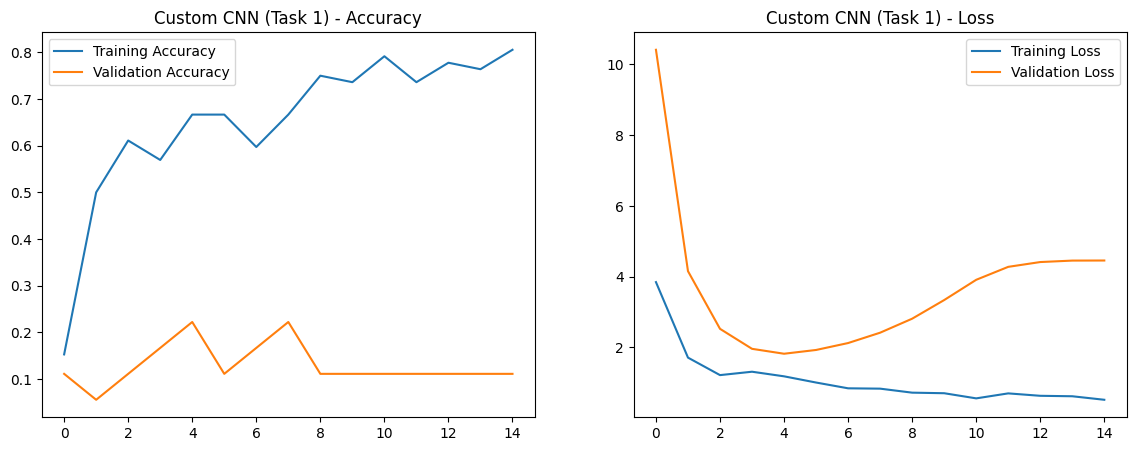

In [ ]:
plot_history(custom_history, "Custom CNN (Task 1)")

In [41]:
custom_model.save('Pratisha_Bista_2408284_Custom_CNN_W6.h5')
print("Custom model saved as 'Pratisha_Bista_2408284_Custom_CNN_W6.h5'")

Custom model saved as 'Pratisha_Bista_2408284_Custom_CNN_W6.h5'


## Task 3: Transfer learning with VGG16

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions to a single vector
x = Dense(1024, activation='relu')(x) # Fully connected layer
outputs = Dense(num_classes, activation='softmax')(x) # Final output layer

vgg_model = Model(inputs=base_model.input, outputs=outputs)

# Compile and Fit the model
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nTraining Transfer Learning Model (VGG16)")
vgg_history = vgg_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)


Training Transfer Learning Model (VGG16)
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.1250 - loss: 1.9613 - val_accuracy: 0.1667 - val_loss: 1.8355
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 13s/step - accuracy: 0.3333 - loss: 1.5637 - val_accuracy: 0.2778 - val_loss: 1.7934
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.4444 - loss: 1.3836 - val_accuracy: 0.5000 - val_loss: 1.5991
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 12s/step - accuracy: 0.7083 - loss: 1.1718 - val_accuracy: 0.3333 - val_loss: 1.4932
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.7222 - loss: 1.0392 - val_accuracy: 0.5000 - val_loss: 1.4320
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 12s/step - accuracy: 0.8194 - loss: 0.9147 - val_accuracy: 0.6111 - val_loss: 1.3593
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 13s/step - accuracy: 0.8056 - loss: 0.8403 - val_accuracy: 0.5556 - val_loss: 1.3363
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 11s/step - accuracy: 0.8611 - loss: 0.7462 

In [42]:
vgg_model.save('Pratisha_Bista_2408284_VGG16_Transfer_W6.h5')
print("VGG16 model saved as 'Pratisha_Bista_2408284_VGG16_Transfer_W6.h5'")

VGG16 model saved as 'Pratisha_Bista_2408284_VGG16_Transfer_W6.h5'


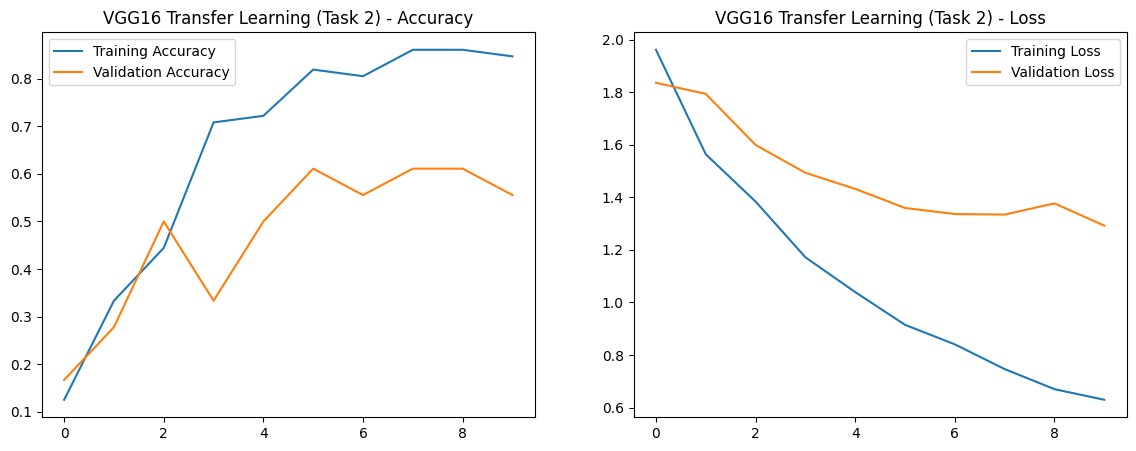

In [ ]:
plot_history(vgg_history, "VGG16 Transfer Learning (Task 2)")

## Task 4: Visualization & classification report

In [ ]:
print("\n[VGG16] Predicting on Test Set")
y_pred_probs = vgg_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extract true labels from the test dataset
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds], axis=0)

print("\nTask 2 Deliverable: Classification Report (VGG16)")
print(classification_report(y_true, y_pred, target_names=class_names))


[VGG16] Predicting on Test Set
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

Task 2 Deliverable: Classification Report (VGG16)
              precision    recall  f1-score   support

        acai       0.40      0.40      0.40         5
     cupuacu       0.12      0.20      0.15         5
    graviola       0.20      0.20      0.20         5
     guarana       0.25      0.20      0.22         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.16      0.17      0.16        30
weighted avg       0.16      0.17      0.16        30

